<a href="https://colab.research.google.com/github/ys23-lys/ESAA/blob/main/ESAA_OB_WEEK13_%ED%95%84%EC%82%AC2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 13.3 적대적 생성 신경망(GAN)이란

GAN(Generative Adversarial Network, GAN): 생성 모델이 최대한 진짜와 비슷한 데이터를 생성하려는 생성자와 진짜와 가짜를 구분하려는 판별자가 각각 존재하여 서로 적대적으로 학습.
1. 판별자를 먼저 학습시킨 후 생성자를 학습시킴. (실제 이미지를 입력해 네트워크가 해당 이미지를 진짜로 분류하도록 학습시킴. 생성자가 생성한 모조 이미지를 입력해 해당 이미지를 가짜로 분류하도록 학습시킴.)
2. 학습 과정을 반복해 판별자와 생성자가 서로를 적대적인 경쟁자로 인식해 발전.

## 13.3.1 GAN 동작 원리

판별자 D: 주어진 입력 이미지가 진짜 이미지인지 가짜 이미지인지 구별.

생성자 G: 판별자 D가 진짜인지 가짜인지 구별할 수 없을 만큼 진짜와 같은 모조 이미지를 노이즈 데이터를 사용하여 만들어 냄.

## 13.3.2 GAN 구현

In [2]:
# 코드 13-22 라이브러리 호출
import imageio
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset,DataLoader
import matplotlib.pylab as plt

from torchvision.utils import make_grid,save_image
import torchvision.datasets as datasets
import torchvision.transforms as transforms
plt.style.use('ggplot')
device=torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [3]:
# 코드 13-23 변수 값 설정
batch_size=512
epochs=200
sample_size=64
nz=128
k=1

In [4]:
# 코드 13-24 MNIST를 내려받은 후 정규화
transform=transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,),(0.5,))
])
train_dataset=datasets.MNIST(root='../chap13/data',train=True,transform=transform,download=True)
train_loader=DataLoader(train_dataset,batch_size=batch_size,shuffle=True,num_workers=4)

100%|██████████| 9.91M/9.91M [00:01<00:00, 5.07MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 132kB/s]
100%|██████████| 1.65M/1.65M [00:01<00:00, 1.25MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 8.93MB/s]
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


In [5]:
# 코드 13-25 생성자 네트워크 생성
class Generator(nn.Module):
  def __init__(self,nz):
    super(Generator,self).__init__()
    self.nz=nz
    self.main=nn.Sequential(
        nn.Linear(self.nz,256),
        nn.LeakyReLU(0.2),
        nn.Linear(256,512),
        nn.LeakyReLU(0.2),
        nn.Linear(512,1024),
        nn.LeakyReLU(0.2),
        nn.Linear(1024,784),
        nn.Tanh(),
    )
  def forward(self,x):
    return self.main(x).view(-1,1,28,28)

In [6]:
# 코드 13-26 판별자 네트워크 생성
class Discriminator(nn.Module):
  def __init__(self):
    super(Discriminator,self).__init__()
    self.n_input=784
    self.main=nn.Sequential(
        nn.Linear(self.n_input,1024),
        nn.LeakyReLU(0.2),
        nn.Dropout(0.3),
        nn.Linear(1024,512),
        nn.LeakyReLU(0.2),
        nn.Dropout(0.3),
        nn.Linear(512,256),
        nn.LeakyReLU(0.2),
        nn.Dropout(0.3),
        nn.Linear(256,1),
        nn.Sigmoid(),
    )
  def forward(self,x):
    x=x.view(-1,784)
    return self.main(x)

In [7]:
# 코드 13-27 생성자와 판별자 네트워크 초기화
generator=Generator(nz).to(device)
discriminator=Discriminator().to(device)
print(generator)
print(discriminator)

Generator(
  (main): Sequential(
    (0): Linear(in_features=128, out_features=256, bias=True)
    (1): LeakyReLU(negative_slope=0.2)
    (2): Linear(in_features=256, out_features=512, bias=True)
    (3): LeakyReLU(negative_slope=0.2)
    (4): Linear(in_features=512, out_features=1024, bias=True)
    (5): LeakyReLU(negative_slope=0.2)
    (6): Linear(in_features=1024, out_features=784, bias=True)
    (7): Tanh()
  )
)
Discriminator(
  (main): Sequential(
    (0): Linear(in_features=784, out_features=1024, bias=True)
    (1): LeakyReLU(negative_slope=0.2)
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=1024, out_features=512, bias=True)
    (4): LeakyReLU(negative_slope=0.2)
    (5): Dropout(p=0.3, inplace=False)
    (6): Linear(in_features=512, out_features=256, bias=True)
    (7): LeakyReLU(negative_slope=0.2)
    (8): Dropout(p=0.3, inplace=False)
    (9): Linear(in_features=256, out_features=1, bias=True)
    (10): Sigmoid()
  )
)


In [8]:
# 코드 13-28 옵티마이저와 손실 함수 정의
optim_g=optim.Adam(generator.parameters(),lr=0.0002)
optim_d=optim.Adam(discriminator.parameters(),lr=0.0002)

criterion=nn.BCELoss()

losses_g=[]
losses_d=[]
images=[]

In [9]:
# 코드 13-29 생성된 이미지 저장 함수 정의
def save_generator_image(image,path):
  save_image(image,path)

In [10]:
# 코드 13-30 판별자 학습을 위한 함수
def train_discriminator(optimizer,data_real,data_fake):
  b_size=data_real.size(0)
  real_label=torch.ones(b_size,1).to(device)
  fake_label=torch.zeros(b_size,1).to(device)
  optimizer.zero_grad()
  output_real=discriminator(data_real)
  loss_real=criterion(output_real,real_label)
  output_fake=discriminator(data_fake)
  loss_fake=criterion(output_fake,fake_label)
  loss_real.backward()
  loss_fake.backward()
  optimizer.step()
  return loss_real+loss_fake

In [11]:
# 코드 13-31 생성자 학습을 위한 함수
def train_generator(optimizer,data_fake):
  b_size=data_fake.size(0)
  real_label=torch.ones(b_size,1).to(device)
  optimizer.zero_grad()
  output=discriminator(data_fake)
  loss=criterion(output,real_label)
  loss.backward()
  optimizer.step()
  return loss

In [14]:
# 코드 13-32 모델 학습
import os

batch_size = 64
epochs = 30
generator.train()
discriminator.train()

# Create directory for saving images if it doesn't exist
os.makedirs("./chap13/img", exist_ok=True)

for epoch in range(epochs):
  loss_g=0.0
  loss_d=0.0
  for idx,data in tqdm(enumerate(train_loader),total=int(len(train_dataset)/train_loader.batch_size)):
    image,_=data
    image=image.to(device)
    b_size=len(image)
    for step in range(k):

      data_fake=generator(torch.randn(b_size,nz).to(device)).detach()
      data_real=image
      loss_d+=train_discriminator(optim_d,data_real,data_fake)
    # Train Generator
    data_fake=generator(torch.randn(b_size,nz).to(device)) # Generate new fake data for generator training
    loss_g+=train_generator(optim_g,data_fake) # Corrected: Use train_generator instead of train_discriminator

  # Generate images for visualization
  generated_img=generator(torch.randn(sample_size,nz).to(device)) # Corrected: Pass random noise to generator
  generated_img=make_grid(generated_img)
  save_generator_image(generated_img,f"./chap13/img/gen_img(epoch).png")
  epoch_loss_g=loss_g/len(train_loader) # Corrected: Use len(train_loader) for consistency
  epoch_loss_d = loss_d / len(train_loader)
  losses_g.append(loss_g/len(train_loader))
  losses_d.append(loss_d/len(train_loader))

  print(f"Epoch {epoch} of {epochs}")
  print(f"Generator loss: {epoch_loss_g:.8f}, Discriminator loss: {epoch_loss_d:.8f}")

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()
118it [00:12,  9.51it/s]                         

Epoch 0 of 30
Generator loss: 19.90015984, Discriminator loss: 0.39622512



118it [00:12,  9.40it/s]                         

Epoch 1 of 30
Generator loss: 7.13455820, Discriminator loss: 0.62466061



118it [00:12,  9.29it/s]

...

Epoch 27 of 30
Generator loss: 19.23420906, Discriminator loss: 0.00000532



118it [00:11, 10.66it/s]                         

Epoch 28 of 30
Generator loss: 19.32616234, Discriminator loss: 0.00000482



118it [00:11, 10.50it/s]                         

Epoch 29 of 30
Generator loss: 19.43404388, Discriminator loss: 0.00000446


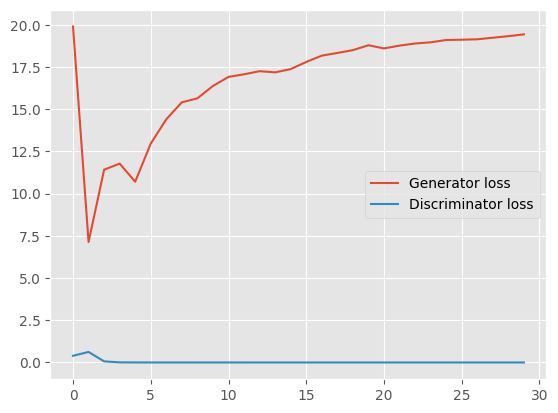

In [15]:
# 코드 13-33 생성자와 판별자의 오차 확인
plt.figure()
losses_g=[fl.item() for fl in losses_g]
plt.plot(losses_g,label="Generator loss")
losses_d=[fl.item() for fl in losses_d]
plt.plot(losses_d,label="Discriminator loss")
plt.legend()

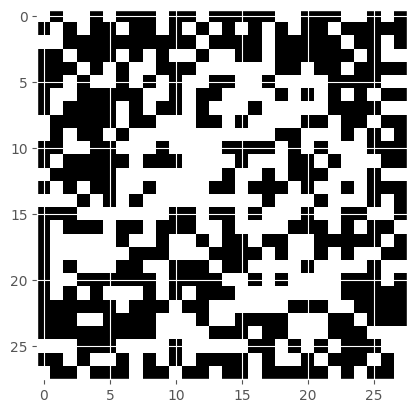

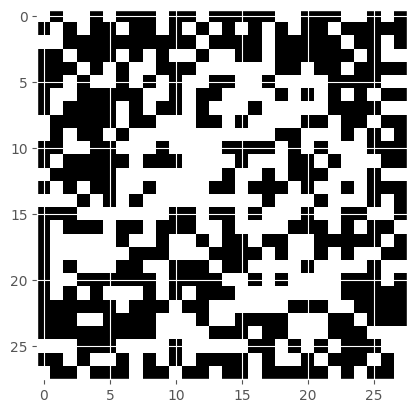

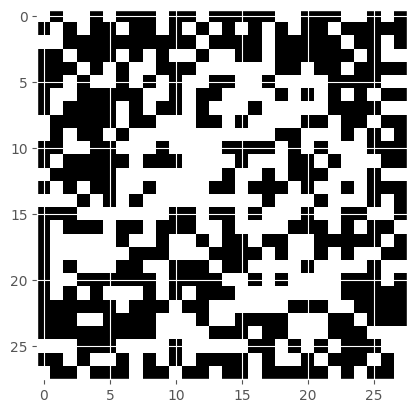

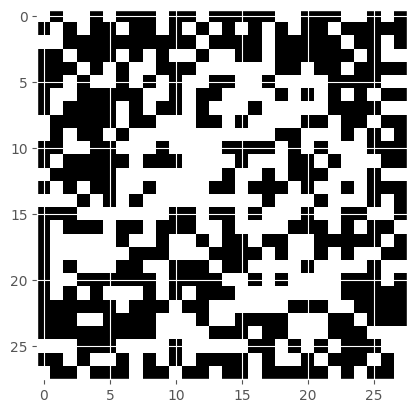

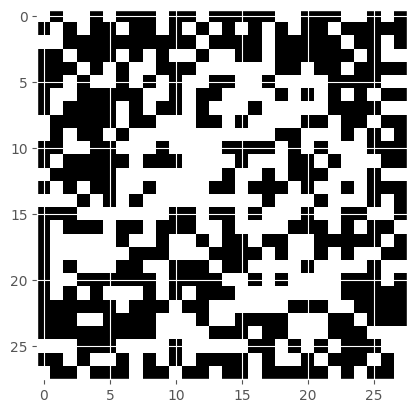

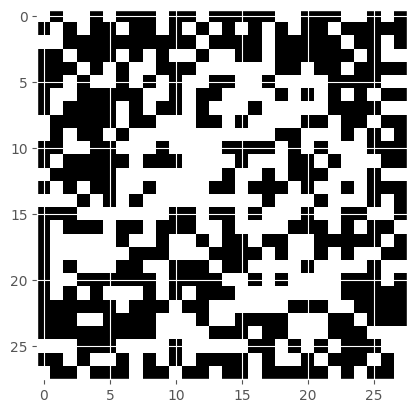

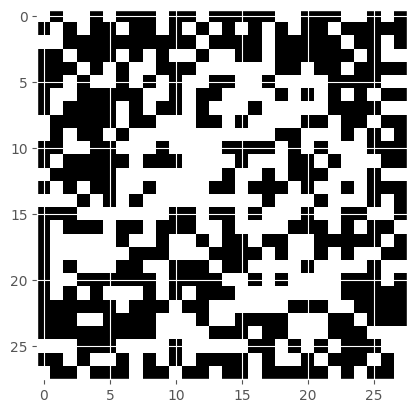

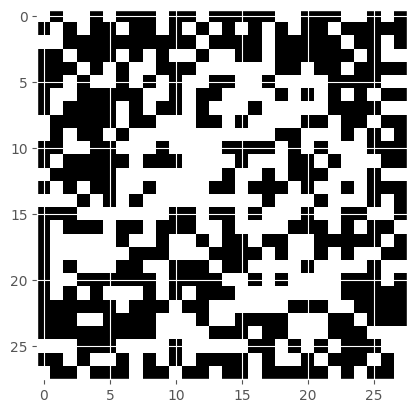

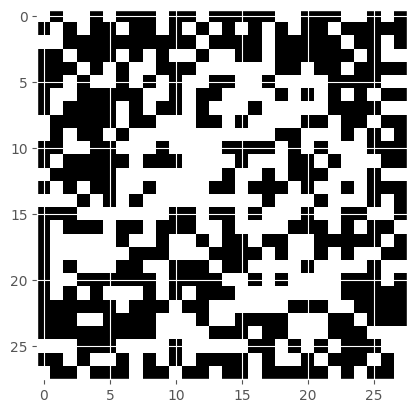

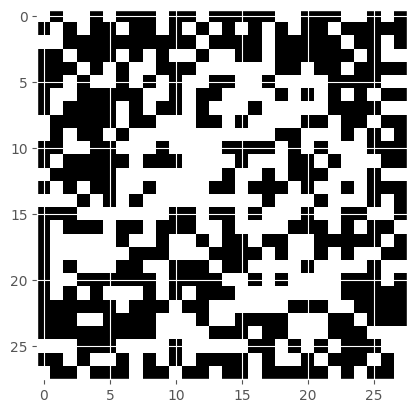

In [18]:
# 코드 13-34 생성된 이미지 출력
import numpy as np
import os

# Create the directory if it doesn't exist
os.makedirs('../chap13/img', exist_ok=True)

fake_images=generator(torch.randn(b_size,nz).to(device))
for i in range(10):
  fake_images_img=np.reshape(fake_images.data.cpu().numpy()[i],(28,28))
  plt.imshow(fake_images_img,cmap='gray')
  plt.savefig('../chap13/img/fake_images_img'+str(i)+'.png')
  plt.show()

# 13.4 GAN 파생 기술

DCGAN(Deep Convolutional GAN) 생성자와 판별자 중 한쪽으로 치우친 훈련이 발생하면 성능에 문제가 생겨 정상적인 분류가 불가능하므로 이 제약을 해결한 모델. GAN 학습에 CNN 사용.

cGAN(convolutional GAN): 출력에 어떤 조건을 주어 변형하는 모델. 시드 역할을 하는 임의의 노이즈와 함께 조건 추가.

CycleGAN: 사진이 주어졌을 때 다른 사진으로 변형시키는 모델

## 13.4.1 DCGAN

입력된 이미지를 바탕으로 그것과 매우 유사한 가짜 이미지를 만들고, 이를 평가하는 과정을 반복해 실제와 매우 유사한 이미지를 생성하는 학습법

**생성자 네트워크**
- 풀링층을 모두 없애고, 분수-스트라이드 합성곱을 사용.
- 배치 정규화를 이용하여 네트워크의 층이 많아도 안정적으로 기울기를 계산하도록 함.
- 활성화 함수 렐루 사용. 최종 출력층에서는 하이퍼볼릭 탄젠트 사용.

**판별자 네트워크**
- 풀링층을 모두 없애고, 스트라이드 합성곱을 사용.
- 배치 정규화를 이용하여 네트워크의 층이 많아도 안정적으로 기울기를 계산하도록 함.
- 활성화 함수 리키렐루 사용. 최종 출력층에서는 시그모이드 사용.

**스트라이드 합성곱과 분수-스트라이드 합성곱**

생성자 네트워크에서는 노이즈를 입력으로 받아 훈련 데이터셋의 이미지와 같은 해상도를 갖는 이미지를 생성해야 함. 공간을 확장시키는 분수-스트라이드 합성곱 필요.

판별자 네트워크는 실제 이미지와 생성자가 생성한 이미지 사이에서 어떤 이미지가 진짜인지 판별해야 하기 때문에 이미지의 특성을 추출할 수 있는 합성곱 연산을 수행, 스트라이드 합성곱을 사용해 특성을 추출.

## 13.4.2 cGAN

생성자와 판별자에 조건을 추가하며 이미지에 대한 변형(기존 이미지에서 변형된 이미지를 생성)하도록 함.

## 13.4.3 CycleGAN

**PIX2PIX**

임의의 노이즈 벡터가 아닌 이미지를 입력으로 받아 다른 스타일의 이미지를 출력하는 지도 학습 알고리즘. 데이터 쌍이 필요함.

**생성자 네트워크**: 전체적으로 출력이 줄어들었다가 다시 커지는 인코더-디코더 구조. 인코더에서 입력 데이터의 특징 찾음, 디코더에서 이미지를 생성함.

**판별자 네트워크**: 스트라이드가 2인 합성곱층으로 구성. 뒤의 두 계층은 스트라이드가 1인 밸리드 합성곱을 이용함.

**CycleGAN**: 쌍을 이루지 않는 이미지로 학습할 수 있는 방법. 생성자 2, 판별자 2를 사용함. 이미지 X에서 이미지 Y로 변환하는 것뿐 아니라 역방향으로도 변환 진행. 생성자 학습에 손실 함수 Lcyc 사용.

